In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [20]:
churn_data = pd.read_csv('data/churn.csv')
churn_data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Столбцы таблицы:

RowNumber — номер строки таблицы (это лишняя информация, поэтому можете сразу от неё избавиться)
CustomerId — идентификатор клиента
Surname — фамилия клиента
CreditScore — кредитный рейтинг клиента (чем он выше, тем больше клиент брал кредитов и возвращал их)
Geography — страна клиента (банк международный)
Gender — пол клиента
Age — возраст клиента
Tenure — сколько лет клиент пользуется услугами банка
Balance — баланс на счетах клиента в банке
NumOfProducts — количество услуг банка, которые приобрёл клиент
HasCrCard — есть ли у клиента кредитная карта (1 — да, 0 — нет)
IsActiveMember — есть ли у клиента статус активного клиента банка (1 — да, 0 — нет)
EstimatedSalary — предполагаемая заработная плата клиента
Exited — статус лояльности (1 — ушедший клиент, 0 — лояльный клиент)

### Задания

9.1. Каково соотношение ушедших и лояльных клиентов? Покажите это на графике и дайте комментарий по соотношению.

9.2. Постройте график, показывающий распределение баланса пользователей, у которых на счету больше 2 500 долларов. Опишите распределение и сделайте выводы.

9.3. Посмотрите на распределение баланса клиента в разрезе признака оттока. Как различаются суммы на накопительном счёте ушедших и лояльных клиентов? Подумайте и напишите, с чем это может быть связано, что может не устраивать ушедших клиентов в банке.

9.4. Посмотрите на распределение возраста в разрезе признака оттока. В какой группе больше потенциальных выбросов? На какую возрастную категорию клиентов стоит обратить внимание банку?

9.5. Постройте график, который показывает взаимосвязь кредитного рейтинга клиента и его предполагаемой зарплаты. Добавьте расцветку по признаку оттока клиентов. Какова взаимосвязь между признаками? Если не видите явной взаимосвязи, укажите это.

9.6. Кто чаще уходит, мужчины или женщины? Постройте график, который иллюстрирует это.

9.7. Как отток клиентов зависит от числа приобретённых у банка услуг? Для ответа на этот вопрос постройте многоуровневую столбчатую диаграмму.

9.8. Как влияет наличие статуса активного клиента на отток клиентов? Постройте диаграмму, иллюстрирующую это. Что бы вы предложили банку, чтобы уменьшить отток клиентов среди неактивных?

9.9. В какой стране доля ушедших клиентов больше? Постройте тепловую картограмму, которая покажет это соотношение на карте мира. Предположите, с чем это может быть связано.

9.10. Переведите числовой признак CreditScore в категориальный. Для этого воспользуйтесь функцией get_credit_score_cat(), которая приведена ниже. Примените её к столбцу CreditScore и создайте новый признак CreditScoreCat — категории кредитного рейтинга.
Постройте сводную таблицу, строками которой являются категории кредитного рейтинга (CreditScoreCat), а столбцами — количество лет, в течение которых клиент пользуется услугами банка (Tenure). В ячейках сводной таблицы должно находиться среднее по признаку оттока (Exited) — доля ушедших пользователей.

На основе полученной сводной таблицы постройте тепловую карту с аннотацией. Найдите на тепловой карте категории клиентов, которые уходят чаще всего.

In [9]:
# Приводим данные в соответствие
churn_data.drop(columns= ['RowNumber'], inplace= True)

#### 9.1. Каково соотношение ушедших и лояльных клиентов? Покажите это на графике и дайте комментарий по соотношению.

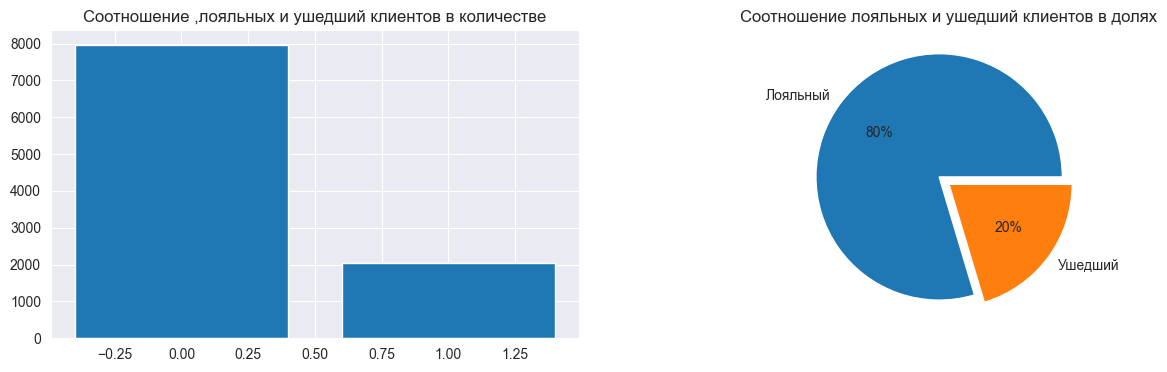

In [10]:
exited = churn_data.groupby(by='Exited',as_index=False)['CustomerId'].count()
churn_data['Exited'] = churn_data['Exited'].apply(lambda x: 'Лояльный' if x == 0 else 'Ушедший')

# визуализация систем координат
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))

# столбчатая диаграмма
axes[0].bar(
    x=exited['Exited'],
    height=exited['CustomerId']
);
axes[0].set_title("Соотношение ,лояльных и ушедший клиентов в количестве");

exited_pie = churn_data.groupby(by='Exited')['CustomerId'].count()
axes[1].pie(
    exited_pie,#берем данные o соотношении клиентов
    labels=exited_pie .index,
    autopct='%.0f%%',#округление до первого знака после запятой
    explode=[0.1,0.0]#доля смещения от центра
);
axes[1].set_title("Соотношение лояльных и ушедший клиентов в долях");

**Вывод:** На графике мы видим, что лояльных клиентов в 4 раза больше, чем ушедших.

#### 9.2. Постройте график, показывающий распределение баланса пользователей, у которых на счету больше 2 500 долларов. Опишите распределение и сделайте выводы.

In [11]:
mask = churn_data['Balance'] >2500
fig_2 = px.histogram(
    data_frame=churn_data[mask],
    x='Balance'
)
fig_2

 **Вывод:** У 190 пользователей в среднем баланс составляет от 122к - до ~124к

#### 9.3. Посмотрите на распределение баланса клиента в разрезе признака оттока. Как различаются суммы на накопительном счёте ушедших и лояльных клиентов? Подумайте и напишите, с чем это может быть связано, что может не устраивать ушедших клиентов в банке.

In [12]:
fig_3 = px.box(
    data_frame=churn_data,
    x='Exited',
    y='Balance'    
)
fig_3

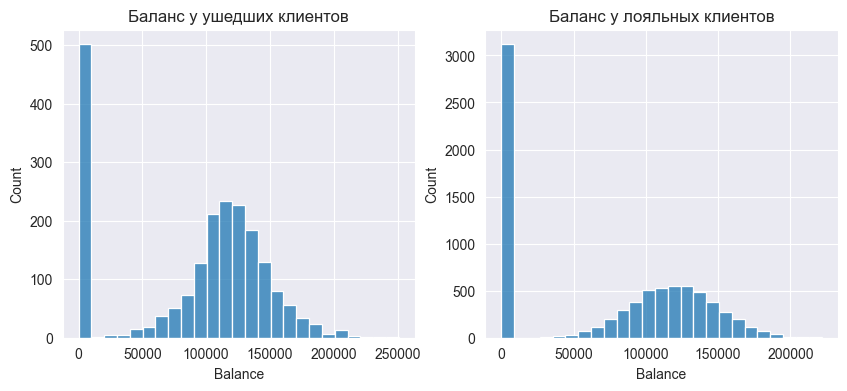

In [13]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,4))
sns.histplot(
    data=churn_data[churn_data['Exited']=='Ушедший'],
    x='Balance',
    bins=25,
    ax=axes[0]
);
axes[0].set_title("Баланс у ушедших клиентов");
sns.histplot(
    data=churn_data[churn_data['Exited']=='Лояльный'],
    x='Balance',
    bins=25,
    ax=axes[1]
);
axes[1].set_title("Баланс у лояльных клиентов");

**Вывод:** В среднем сумма баланса у ушедших клиентов выше, чем у лояльных. Но и количество ушедших клиентов меньше.

#### 9.4. Посмотрите на распределение возраста в разрезе признака оттока. В какой группе больше потенциальных выбросов? На какую возрастную категорию клиентов стоит обратить внимание банку?

In [14]:
fig_4 = px.box(
    data_frame=churn_data,
    x='Age',
    y='Exited',
    orientation='h'   
)
fig_4

**Вывод:** Проанализировав график, можно сделать вывод, что в среднем ушедшие клиенты относятся к группе вотПроанализировав график, можно сделать вывод, что в среднем ушедшие клиенты относятся к группе от 38 до 51 года (средний возраст 41 год). Лояльные клиенты имеют более молодой возраст от 31 до 41 года (средний возраст 36 лет).
Банку стоит обратить внимание на продукты для возрастной группы 38+.

#### 9.5. Постройте график, который показывает взаимосвязь кредитного рейтинга клиента и его предполагаемой зарплаты. Добавьте расцветку по признаку оттока клиентов. Какова взаимосвязь между признаками? Если не видите явной взаимосвязи, укажите это.

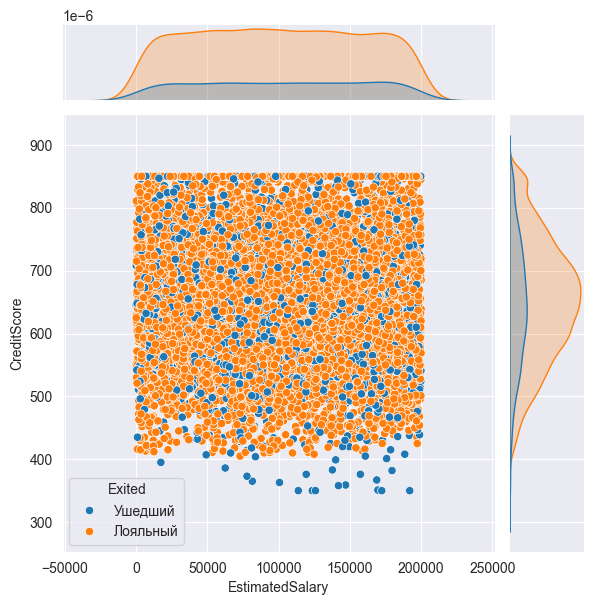

In [15]:
#строим график
fig_5=sns.jointplot(
    data=churn_data,
    x='EstimatedSalary',
    y='CreditScore',
    hue='Exited'
)

**Вывод:** Отсутствует связь между кредитным рейтингом и зарплатой.

#### 9.6. Кто чаще уходит, мужчины или женщины? Постройте график, который иллюстрирует это.

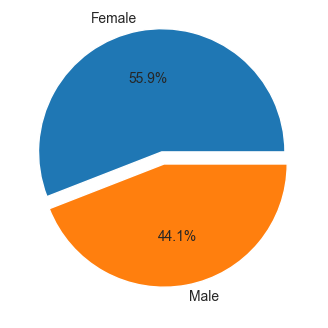

In [16]:
gone= churn_data[churn_data['Exited']=='Ушедший']['Gender'].value_counts()
fig_6, axes_6 = plt.subplots(figsize=(4,4))
axes_6.pie(
    x=gone,
    labels= gone.index,
    autopct='%.1f%%',#округление до первого знака после запятой
    explode=[0.1,0.0]#доля смещения от центра
);

**Вывод:** Немного чаще уходят женщины, чем мужчины. Но незначительно.

#### 9.7. Как отток клиентов зависит от числа приобретённых у банка услуг? Для ответа на этот вопрос постройте многоуровневую столбчатую диаграмму.

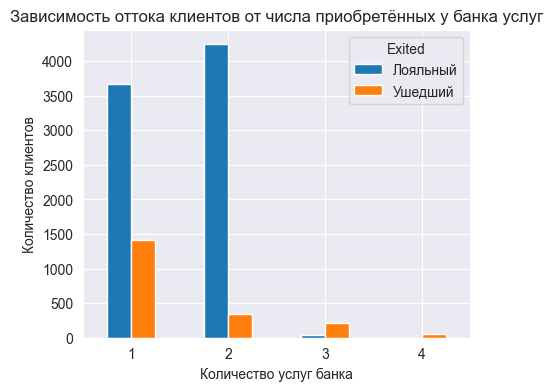

In [17]:
# делаем сводную таблицу
pivot_1 = churn_data.pivot_table(
    'CustomerId',
    index='NumOfProducts',
    columns='Exited',
    aggfunc='count'
)
pivot_1 = pivot_1.fillna(0)# заменяем на 0 возможные пропуски данных

#строим график
fig_7, axes_7 = plt.subplots(figsize=(5,4))
pivot_1.plot(
    kind='bar',
    ax=axes_7
);
axes_7.set_title('Зависимость оттока клиентов от числа приобретённых у банка услуг');
axes_7.set_xlabel('Количество услуг банка');
axes_7.set_ylabel('Количество клиентов');
axes_7.xaxis.set_tick_params(rotation=360)

**Вывод:** Из графика можно сделать вывод, что ушедшие клиенты чаще пользуются большим количеством продуктов Банка, возможно это активные клиенты, которые смотрят на преспективные продукты в Банках и не акцентируют свое внимание только на одном Банке. Новый интересный продукт или услуга заставляет их уходить из одного Банка в другой.
Напротив, лояльные клиенты, практически не используют более 2 услуг, что может свидетельствовать о их менее активной поиске новых услуг по кредитной карте (стабильность и понятные продукты, критерий качества).

#### 9.8. Как влияет наличие статуса активного клиента на отток клиентов? Постройте диаграмму, иллюстрирующую это. Что бы вы предложили банку, чтобы уменьшить отток клиентов среди неактивных?

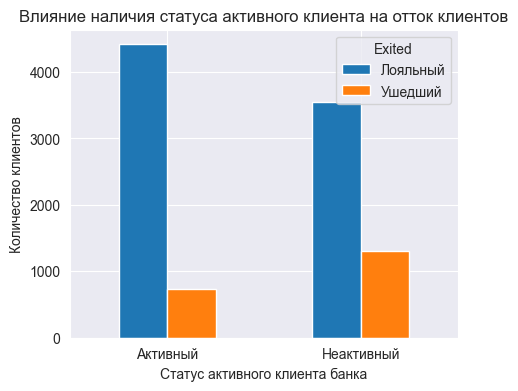

In [18]:
# делаем сводную таблицу
churn_data['IsActiveMember'] = churn_data['IsActiveMember'].apply(lambda x: 'Неактивный' if x == 0 else 'Активный')
pivot_2 = churn_data.pivot_table(
    'CustomerId',
    index='IsActiveMember',
    columns='Exited',
    aggfunc='count'
)
pivot_2 = pivot_2.fillna(0)# заменяем на 0 возможные пропуски данных
#строим график
fig_8, axes_8 = plt.subplots(figsize=(5,4))
pivot_2.plot(
    kind='bar',
    ax=axes_8
);
axes_8.set_title('Влияние наличия статуса активного клиента на отток клиентов');
axes_8.set_xlabel('Cтатус активного клиента банка');
axes_8.set_ylabel('Количество клиентов');
axes_8.xaxis.set_tick_params(rotation=360);

**Вывод:** Неактивные клиенты, почти в 2 раза чаще покидают Банк. Возможно, внедрение новой услуги, по уменьшению комиссии за обслуживание неактивного счета, поможет удержать неактивных клиентов, сохранив тем самым базу клиентов.

#### 9.9. В какой стране доля ушедших клиентов больше? Постройте тепловую картограмму, которая покажет это соотношение на карте мира. Предположите, с чем это может быть связано.

In [19]:
churn_data['Exited'] = churn_data['Exited'].apply(lambda x: 1 if x == 'Ушедший' else 0)
# делаем сводную таблицу
pivot_3 = churn_data.pivot_table(
    values='Exited',
    index='Geography',
    aggfunc= 'mean',
)
#строим график
fig_9 = px.choropleth(
    data_frame=pivot_3, 
    locations=pivot_3.index, 
    locationmode = "country names", 
    color= 'Exited', 
    range_color=[0, 0.35], 
    title='Доля потерянных клиентов по странам', 
    width=800,
    height=500,
    color_continuous_scale='Reds'
)
#отображаем график
fig_9.show()

C:\Users\Metal\AppData\Local\Temp\ipykernel_3204\2741028637.py:9: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig_9 = px.choropleth(


**Вывод:** Больший отток клиентов наблюдается в Германии. Предположу, что это немецкий Банк, поэтому и доля ушедших клиентов выше в Германии.

#### 9.10. Переведите числовой признак CreditScore в категориальный. Для этого воспользуйтесь функцией get_credit_score_cat(), которая приведена ниже. Примените её к столбцу CreditScore и создайте новый признак CreditScoreCat — категории кредитного рейтинга. Постройте сводную таблицу, строками которой являются категории кредитного рейтинга (CreditScoreCat), а столбцами — количество лет, в течение которых клиент пользуется услугами банка (Tenure). В ячейках сводной таблицы должно находиться среднее по признаку оттока (Exited) — доля ушедших пользователей.

In [14]:
def get_credit_score_cat(credit_score):
    if credit_score >= 300 and credit_score < 500:
        return "Very_Poor"
    elif credit_score >= 500 and credit_score < 601:
        return "Poor"
    elif credit_score >= 601 and credit_score < 661:
        return "Fair"
    elif credit_score >= 661 and credit_score < 781:
        return "Good"
    elif credit_score >= 781 and credit_score < 851:
        return "Excellent"
    elif credit_score >= 851:
        return "Top"
    elif credit_score < 300:
        return "Deep"

In [15]:
#создаем новый признак 'CreditScoreCat'
churn_data['CreditScoreCat']=churn_data['CreditScore'].apply(get_credit_score_cat)

In [16]:
# делаем сводную таблицу
pivot_4 = churn_data.pivot_table(
    values='Exited',
    index='CreditScoreCat',
    columns='Tenure',
    aggfunc= 'mean',
)

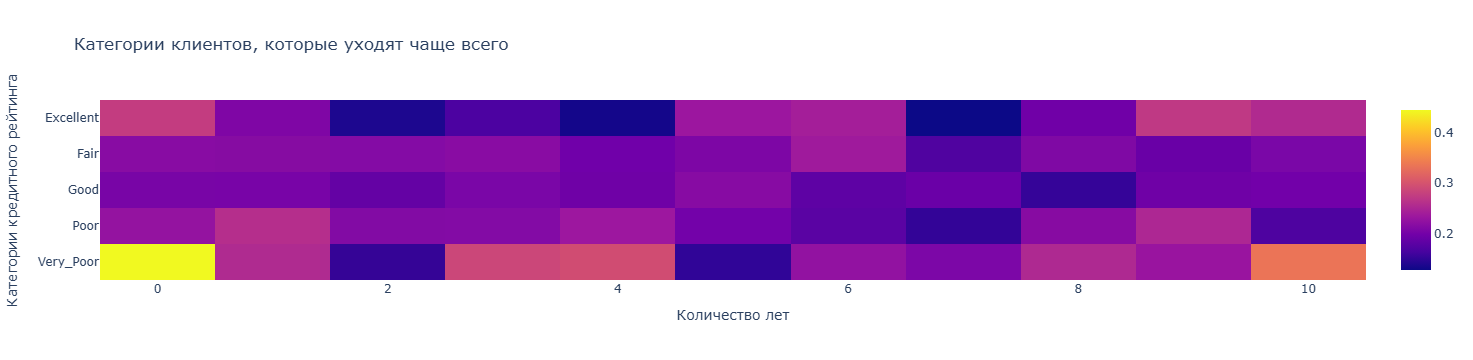

In [17]:
#строим график
fig_10 = px.imshow(    
    pivot_4,
    labels={'x': 'Количество лет', 'y': 'Категории кредитного рейтинга'},
    title='Категории клиентов, которые уходят чаще всего'
)
#отображаем график
fig_10

**Вывод:**
Для успешной работы банку необходимо заверить клиентов в своей надежности, чтобы клиенты хранили большие суммы на своих счетах, чтобы уменьшить количество клиентов с нулевыми счетами.
Обновить программы по вкладам, возможно разработать программу по повышенной выплате процентов за вклад для старых клиентов, чтобы избежать их ухода.
Предложить высокий процент на остаток, чтобы клинты всегда хранили на своем счете какую-либо сумму.
Обратить внимание на основную аудиторию банка, которая находятся в возрастной категории от 31-38 лет, создать какие-то выгодные условия конкретно для этой возрастной категории.
Обновить предоставляемые услуги для клиентов, сделать специальные предложения.